Analiza jucatorilor de fotbal - sezon 2025/2026

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Bibliotecile au fost importate cu succes')

Bibliotecile au fost importate cu succes


1. Incarcarea si curatarea datelor

In [33]:
df = pd.read_csv('players_data-2025_2026.csv')
print(f'Datele au fost încărcate. Baza de date are {df.shape[0]} jucători și {df.shape[1]} coloane.')
display(df.head())

Datele au fost încărcate. Baza de date are 2751 jucători și 102 coloane.


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,32,26,...,2,0,0,18,47,5,36,14,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,...,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,26.0,1999.0,7,1,...,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [34]:
print('--- Informații generale ---')
df.info()
print('\n--- Valori lipsă per coloană (top 15) ---')
print(df.isnull().sum()[df.isnull().sum() > 0].head(15))

--- Informații generale ---
<class 'pandas.DataFrame'>
RangeIndex: 2751 entries, 0 to 2750
Columns: 102 entries, Rk to OG
dtypes: float64(41), int64(40), str(21)
memory usage: 2.1 MB

--- Valori lipsă per coloană (top 15) ---
Nation                    2
Age                       1
Born                      1
Rk_stats_keeper        2576
Nation_stats_keeper    2576
Pos_stats_keeper       2576
Comp_stats_keeper      2576
Age_stats_keeper       2576
Born_stats_keeper      2576
MP_stats_keeper        2576
Starts_stats_keeper    2576
Min_stats_keeper       2576
90s_stats_keeper       2576
GA                     2576
GA90                   2576
dtype: int64


In [35]:
# Păstrăm doar prima poziție (în cazul jucătorilor cu roluri multiple)
df['Pos'] = df['Pos'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

jucatori_initial = len(df)
df = df[df['Min'] >= 450]
print(f'Am eliminat {jucatori_initial - len(df)} jucători cu prea puține minute jucate.')

# Eliminăm coloanele duplicate generate de join-uri FBref
cols_de_sters = [c for c in df.columns if any(s in c for s in [
    '_stats_keeper', '_stats_shooting', '_stats_playing_time', '_stats_misc'
])]
df = df.drop(columns=cols_de_sters, errors='ignore')
df = df.drop(columns=['Rk'], errors='ignore')
df = df.dropna(subset=['Player', 'Pos', 'Min'])

# Curățare coloane Nation și Comp
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)
df['Comp']   = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)
df['Age']    = df['Age'].astype(float).astype('Int64')
df['Born']   = df['Born'].astype(float).astype('Int64')

print(f'\nBaza de date curățată a rămas cu {len(df)} jucători gata pentru analiză.')
print(f'Distribuție pe poziții:\n{df["Pos"].value_counts()}')

Am eliminat 844 jucători cu prea puține minute jucate.

Baza de date curățată a rămas cu 1907 jucători gata pentru analiză.
Distribuție pe poziții:
Pos
MF    871
DF    617
FW    289
GK    130
Name: count, dtype: int64


2. Explorarea datelor (EDA)

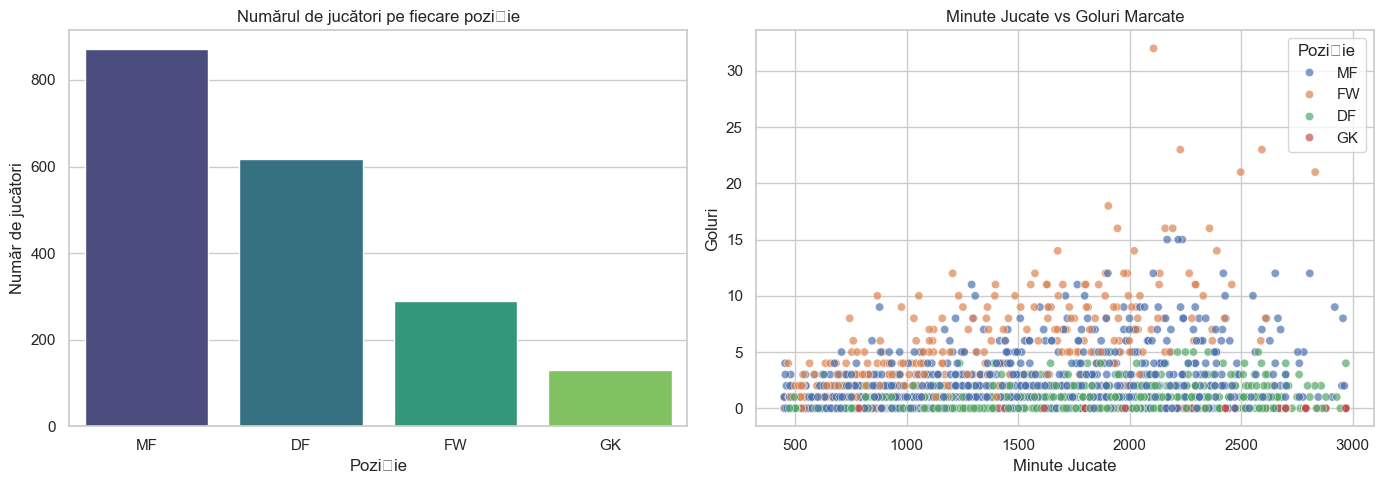

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafic 1: Distribuția jucătorilor pe poziții
sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index,
              palette='viridis', ax=axes[0])
axes[0].set_title('Numărul de jucători pe fiecare poziție')
axes[0].set_xlabel('Poziție')
axes[0].set_ylabel('Număr de jucători')

# Grafic 2: Relația dintre Minute Jucate și Goluri marcate
sns.scatterplot(data=df, x='Min', y='Gls', hue='Pos', alpha=0.7, ax=axes[1])
axes[1].set_title('Minute Jucate vs Goluri Marcate')
axes[1].set_xlabel('Minute Jucate')
axes[1].set_ylabel('Goluri')
axes[1].legend(title='Poziție')

plt.tight_layout()
plt.show()

In [37]:
# 'eng ENG' devine 'ENG'
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)

# 'eng Premier League' devine 'Premier League'
df['Comp'] = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)

df['Age'] = df['Age'].astype(float).astype('Int64')
df['Born'] = df['Born'].astype(float).astype('Int64')

display(df[['Player', 'Nation', 'Comp', 'Age']].head())

,Player,Nation,Comp,Age
0,Brenden Aaronson,USA,League,25
2,Jones El-Abdellaoui,MAR,Liga,20
4,Himad Abdelli,ALG,1,26
5,Ali Abdi,TUN,1,32
6,Salis Abdul Samed,GHA,1,26


In [38]:
df.to_csv('players-curatat.csv', index=False)
print("Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.")

Fisierul curatat a fost salvat cu succes ca 'players-curatat.csv'.


3. Ingineria caracteristicilor

In [39]:
# Eficiența finalizării: G/Sh * SoT - Gls (cât de bine valorifică șansele față de așteptări)
df['Eficienta_Finalizare'] = df['G/Sh'].fillna(0) * df['SoT'].fillna(0) - df['Gls'].fillna(0)

# Contribuție ofensivă: goluri (fără penalty) + assisturi
df['Contributie_Ofensiva'] = df['G-PK'].fillna(0) + df['Ast'].fillna(0)

# Implicare defensivă per 90 minute
df['Implicare_Defensiva_90'] = (df['TklW'].fillna(0) + df['Int'].fillna(0)) / (df['90s'] + 0.01)

# Scor portari: normalizare Save% și CS combinate
save_norm = (df['Save%'].fillna(0) - df['Save%'].min()) / (df['Save%'].max() - df['Save%'].min() + 0.01)
cs_norm   = (df['CS'].fillna(0) - df['CS'].min()) / (df['CS'].max() - df['CS'].min() + 0.01)
df['Scor_Portar'] = (save_norm + cs_norm) / 2

# Scor fundaș: implicare defensivă minus penalizare cartonașe
df['Scor_Fundas'] = df['Implicare_Defensiva_90'] - df['CrdY'].fillna(0) * 0.1

# Scor playmaker pentru mijlocași: implicare defensivă + assisturi
df['Scor_Playmaker'] = df['Implicare_Defensiva_90'] + df['Ast'].fillna(0)

# Feature extra: eficiența la duel aerian
if 'Won%' in df.columns:
    df['Eficienta_Aerian'] = df['Won%'].fillna(0)

# Feature extra: presiune aplicată per minut
if 'Press' in df.columns:
    df['Presiune_Per90'] = df['Press'].fillna(0) / (df['90s'] + 0.01)

print('Caracteristicile au fost create cu succes!')
display(df[['Player', 'Pos', 'Contributie_Ofensiva', 'Implicare_Defensiva_90', 'Scor_Portar']].head(10))

Caracteristicile au fost create cu succes!


,Player,Pos,Contributie_Ofensiva,Implicare_Defensiva_90,Scor_Portar
0,Brenden Aaronson,MF,9,1.518347,-0.637945
2,Jones El-Abdellaoui,MF,2,0.843882,-0.637945
4,Himad Abdelli,MF,0,2.854424,-0.637945
5,Ali Abdi,MF,2,1.563858,-0.637945
6,Salis Abdul Samed,MF,0,2.021403,-0.637945
7,Saud Abdulhamid,MF,5,2.195307,-0.637945
9,Laurent Abergel,MF,1,2.106679,-0.637945
10,Matthis Abline,FW,8,0.832986,-0.637945
11,Abner,DF,3,1.155198,-0.637945
12,Zakaria Aboukhlal,MF,0,2.276708,-0.637945


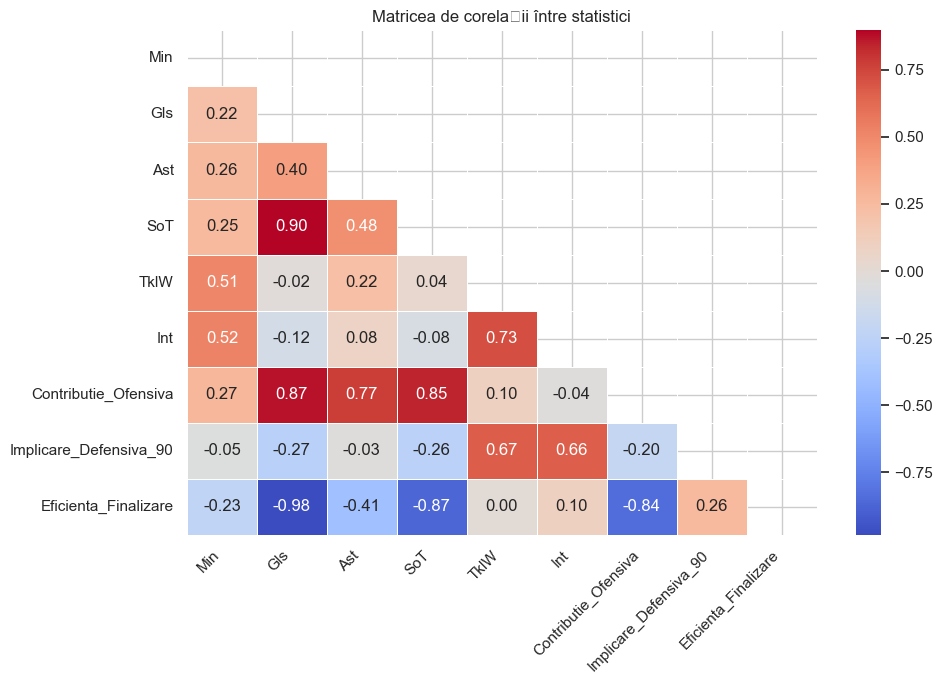

In [40]:
# Matrice de corelații pentru variabilele cheie
coloane_corr = ['Min', 'Gls', 'Ast', 'SoT', 'TklW', 'Int',
                'Contributie_Ofensiva', 'Implicare_Defensiva_90', 'Eficienta_Finalizare']
coloane_corr = [c for c in coloane_corr if c in df.columns]

matrice = df[coloane_corr].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(matrice, dtype=bool))
sns.heatmap(matrice, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Matricea de corelații între statistici')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

4. Implementare și comparare algoritmi ML

Vom antrena și compara 8 algoritmi pentru fiecare poziție:

    Random Forest
    Gradient Boosting
    Extra Trees
    AdaBoost
    Ridge Regression
    Lasso Regression
    SVR (Support Vector Regression)
    KNN Regression
    Decision Tree
    ElasticNet


In [41]:
def antreneaza_si_compara_modele(df_pos, features, target, pos_name):
    """
    Antrenează 10 algoritmi cu optimizare hiperparametri (GridSearchCV)
    și returnează un tabel comparativ cu rezultatele brute.
    """
    df_clean = df_pos.dropna(subset=[target]).copy()
    X = df_clean[features].fillna(0)
    y = df_clean[target]

    if len(X) < 15:
        print(f'Nu sunt suficienți jucători pentru {pos_name}')
        return None, None

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f'\n{"="*65}')
    print(f'  ANTRENARE MODELE PENTRU: {pos_name}')
    print(f'  Train: {len(X_train)} jucători | Test: {len(X_test)} jucători')
    print(f'{"="*65}')

    # ------------------------------------------------------------------ #
    # Definim gridul de hiperparametri pentru fiecare model
    # ------------------------------------------------------------------ #
    configuratii = [
        {
            'nume': 'Random Forest',
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Gradient Boosting',
            'model': GradientBoostingRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5]
            },
            'scaled': False
        },
        {
            'nume': 'Extra Trees',
            'model': ExtraTreesRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            },
            'scaled': False
        },
        {
            'nume': 'AdaBoost',
            'model': AdaBoostRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 1.0]
            },
            'scaled': False
        },
        {
            'nume': 'Ridge Regression',
            'model': Ridge(),
            'params': {'alpha': [0.01, 0.1, 1, 10, 100]},
            'scaled': True
        },
        {
            'nume': 'Lasso Regression',
            'model': Lasso(),
            'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]},
            'scaled': True
        },
        {
            'nume': 'ElasticNet',
            'model': ElasticNet(),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'scaled': True
        },
        {
            'nume': 'SVR',
            'model': SVR(),
            'params': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1, 0.5],
                'kernel': ['rbf', 'linear']
            },
            'scaled': True
        },
        {
            'nume': 'KNN Regression',
            'model': KNeighborsRegressor(),
            'params': {
                'n_neighbors': [3, 5, 7, 10],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'scaled': True
        },
        {
            'nume': 'Decision Tree',
            'model': DecisionTreeRegressor(random_state=42),
            'params': {
                'max_depth': [3, 5, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            'scaled': False
        },
    ]

    rezultate = []
    best_models = {}

    for cfg in configuratii:
        Xtr = X_train_sc if cfg['scaled'] else X_train
        Xte = X_test_sc  if cfg['scaled'] else X_test

        grid = GridSearchCV(cfg['model'], cfg['params'], cv=5,
                            scoring='r2', n_jobs=-1, refit=True)
        grid.fit(Xtr, y_train)
        best = grid.best_estimator_
        y_pred = best.predict(Xte)

        cv_scores = cross_val_score(best, Xtr, y_train, cv=5, scoring='r2')

        mse  = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        rezultate.append({
            'Model': cfg['nume'],
            'R²': round(r2, 4),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'MSE': round(mse, 4),
            'CV R² (mean)': round(cv_scores.mean(), 4),
            'CV R² (std)': round(cv_scores.std(), 4),
            'Best Params': str(grid.best_params_)
        })

        print(f'  ✓ {cfg["nume"]:22s}  R²={r2:+.4f}  RMSE={rmse:.4f}  Params: {grid.best_params_}')
        best_models[cfg['nume']] = {'model': best, 'y_pred': y_pred}

    rez_df = pd.DataFrame(rezultate).sort_values('R²', ascending=False).reset_index(drop=True)
    rez_df.index += 1
    return rez_df, best_models


print('Funcția de antrenare a fost definită!')

Funcția de antrenare a fost definită!


4.1 Modele pentru Atacanți 

In [42]:
df_fw = df[df['Pos'] == 'FW'].copy()
features_fw = ['Min', 'SoT', 'G/Sh', 'Eficienta_Finalizare', 'Implicare_Defensiva_90', 'CrdY', 'Age']
features_fw = [f for f in features_fw if f in df_fw.columns]

rez_fw, models_fw = antreneaza_si_compara_modele(
    df_fw, features_fw, 'Contributie_Ofensiva', 'FW - ATACANȚI'
)
print('\n--- Tabel Comparativ Rezultate Brute: ATACANȚI ---')
display(rez_fw)


  ANTRENARE MODELE PENTRU: FW - ATACANȚI
  Train: 231 jucători | Test: 58 jucători
  ✓ Random Forest           R²=+0.8944  RMSE=1.5697  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ Gradient Boosting       R²=+0.8715  RMSE=1.7315  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
  ✓ Extra Trees             R²=+0.8471  RMSE=1.8883  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  ✓ AdaBoost                R²=+0.8918  RMSE=1.5885  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+0.8733  RMSE=1.7189  Params: {'alpha': 10}
  ✓ Lasso Regression        R²=+0.8709  RMSE=1.7351  Params: {'alpha': 0.1}
  ✓ ElasticNet              R²=+0.8711  RMSE=1.7340  Params: {'alpha': 0.1, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.8671  RMSE=1.7605  Params: {'C': 1, 'epsilon': 0.5, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.8060  RMSE=2.1271  Params: {'metric': 'euclidean', 'n_n

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,Random Forest,0.8944,1.5697,1.2174,2.4639,0.7512,0.0488,"{'max_depth': None, 'min_samples_split': 2, 'n..."
2,AdaBoost,0.8918,1.5885,1.2696,2.5234,0.7390,0.0372,"{'learning_rate': 1.0, 'n_estimators': 200}"
3,Ridge Regression,0.8733,1.7189,1.2705,2.9546,0.7692,0.0430,{'alpha': 10}
4,Gradient Boosting,0.8715,1.7315,1.3257,2.9982,0.7654,0.0546,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
5,ElasticNet,0.8711,1.7340,1.2775,3.0068,0.7700,0.0453,"{'alpha': 0.1, 'l1_ratio': 0.2}"
6,Lasso Regression,0.8709,1.7351,1.2851,3.0105,0.7685,0.0455,{'alpha': 0.1}
7,SVR,0.8671,1.7605,1.2942,3.0994,0.7647,0.0358,"{'C': 1, 'epsilon': 0.5, 'kernel': 'linear'}"
8,Extra Trees,0.8471,1.8883,1.3312,3.5657,0.7762,0.0323,"{'max_depth': None, 'min_samples_split': 2, 'n..."
9,KNN Regression,0.8060,2.1271,1.4703,4.5246,0.7370,0.0312,"{'metric': 'euclidean', 'n_neighbors': 10, 'we..."
10,Decision Tree,0.7343,2.4892,1.5311,6.1960,0.6265,0.1306,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."


4.2 Modele pentru Mijlocași

In [43]:
df_mf = df[df['Pos'] == 'MF'].copy()
features_mf = ['Min', 'Gls', 'Ast', 'TklW', 'Int', 'CrdY', 'Age']
features_mf = [f for f in features_mf if f in df_mf.columns]

rez_mf, models_mf = antreneaza_si_compara_modele(
    df_mf, features_mf, 'Scor_Playmaker', 'MF - MIJLOCAȘI'
)
print('\n--- Tabel Comparativ Rezultate Brute: MIJLOCAȘI ---')
display(rez_mf)


  ANTRENARE MODELE PENTRU: MF - MIJLOCAȘI
  Train: 696 jucători | Test: 175 jucători
  ✓ Random Forest           R²=+0.9534  RMSE=0.5028  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ Gradient Boosting       R²=+0.9877  RMSE=0.2586  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9811  RMSE=0.3203  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ AdaBoost                R²=+0.9100  RMSE=0.6991  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+0.9867  RMSE=0.2690  Params: {'alpha': 1}
  ✓ Lasso Regression        R²=+0.9866  RMSE=0.2692  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+0.9866  RMSE=0.2692  Params: {'alpha': 0.001, 'l1_ratio': 0.8}
  ✓ SVR                     R²=+0.9865  RMSE=0.2711  Params: {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.8596  RMSE=0.8730  Params: {'metric': 'euclidean',

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,Gradient Boosting,0.9877,0.2586,0.1326,0.0669,0.9841,0.0109,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
2,Ridge Regression,0.9867,0.2690,0.1881,0.0724,0.9717,0.0062,{'alpha': 1}
3,ElasticNet,0.9866,0.2692,0.1882,0.0725,0.9717,0.0062,"{'alpha': 0.001, 'l1_ratio': 0.8}"
4,Lasso Regression,0.9866,0.2692,0.1881,0.0725,0.9717,0.0062,{'alpha': 0.001}
5,SVR,0.9865,0.2711,0.1839,0.0735,0.9714,0.0068,"{'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}"
6,Extra Trees,0.9811,0.3203,0.2130,0.1026,0.9737,0.0062,"{'max_depth': None, 'min_samples_split': 2, 'n..."
7,Random Forest,0.9534,0.5028,0.2703,0.2528,0.9551,0.0152,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
8,Decision Tree,0.9244,0.6404,0.4152,0.4101,0.9421,0.0158,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
9,AdaBoost,0.9100,0.6991,0.4873,0.4887,0.9195,0.0138,"{'learning_rate': 1.0, 'n_estimators': 200}"
10,KNN Regression,0.8596,0.8730,0.5697,0.7621,0.8314,0.0233,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei..."


4.3 Modele pentru Fundași 

In [44]:
df_df = df[df['Pos'] == 'DF'].copy()
features_df = ['Min', 'TklW', 'Int', 'Fls', 'CrdY', 'Age', '90s']
features_df = [f for f in features_df if f in df_df.columns]

rez_df, models_df = antreneaza_si_compara_modele(
    df_df, features_df, 'Scor_Fundas', 'DF - FUNDAȘI'
)
print('\n--- Tabel Comparativ Rezultate Brute: FUNDAȘI ---')
display(rez_df)


  ANTRENARE MODELE PENTRU: DF - FUNDAȘI
  Train: 493 jucători | Test: 124 jucători
  ✓ Random Forest           R²=+0.8493  RMSE=0.2456  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ Gradient Boosting       R²=+0.9233  RMSE=0.1752  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.8829  RMSE=0.2165  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ AdaBoost                R²=+0.7189  RMSE=0.3355  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+0.8124  RMSE=0.2741  Params: {'alpha': 0.01}
  ✓ Lasso Regression        R²=+0.8116  RMSE=0.2746  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+0.8117  RMSE=0.2746  Params: {'alpha': 0.001, 'l1_ratio': 0.8}
  ✓ SVR                     R²=+0.9874  RMSE=0.0710  Params: {'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}
  ✓ KNN Regression          R²=+0.6906  RMSE=0.3519  Params: {'metric': 'euclidean'

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,SVR,0.9874,0.0710,0.0419,0.0050,0.9792,0.0109,"{'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}"
2,Gradient Boosting,0.9233,0.1752,0.1228,0.0307,0.9115,0.0115,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,Extra Trees,0.8829,0.2165,0.1536,0.0469,0.8642,0.0165,"{'max_depth': None, 'min_samples_split': 2, 'n..."
4,Random Forest,0.8493,0.2456,0.1808,0.0603,0.8087,0.0152,"{'max_depth': None, 'min_samples_split': 2, 'n..."
5,Ridge Regression,0.8124,0.2741,0.1806,0.0751,0.8204,0.0352,{'alpha': 0.01}
6,ElasticNet,0.8117,0.2746,0.1808,0.0754,0.8202,0.0352,"{'alpha': 0.001, 'l1_ratio': 0.8}"
7,Lasso Regression,0.8116,0.2746,0.1808,0.0754,0.8202,0.0352,{'alpha': 0.001}
8,AdaBoost,0.7189,0.3355,0.2629,0.1125,0.6940,0.0169,"{'learning_rate': 1.0, 'n_estimators': 200}"
9,KNN Regression,0.6906,0.3519,0.2632,0.1239,0.6403,0.0340,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei..."
10,Decision Tree,0.6774,0.3594,0.2748,0.1292,0.5062,0.0954,"{'max_depth': None, 'min_samples_leaf': 4, 'mi..."


4.4 Modele pentru Portari 

In [45]:
df_gk = df[df['Pos'] == 'GK'].copy()
features_gk_all = ['Min', 'Save%', 'CS', 'GA90', 'Age', 'SoTA']
features_gk = [f for f in features_gk_all if f in df_gk.columns]

rez_gk, models_gk = antreneaza_si_compara_modele(
    df_gk, features_gk, 'Scor_Portar', 'GK - PORTARI'
)
print('\n--- Tabel Comparativ Rezultate Brute: PORTARI ---')
display(rez_gk)


  ANTRENARE MODELE PENTRU: GK - PORTARI
  Train: 104 jucători | Test: 26 jucători
  ✓ Random Forest           R²=+0.9719  RMSE=0.0254  Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
  ✓ Gradient Boosting       R²=+0.9818  RMSE=0.0204  Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
  ✓ Extra Trees             R²=+0.9912  RMSE=0.0142  Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✓ AdaBoost                R²=+0.9629  RMSE=0.0292  Params: {'learning_rate': 1.0, 'n_estimators': 200}
  ✓ Ridge Regression        R²=+1.0000  RMSE=0.0000  Params: {'alpha': 0.01}
  ✓ Lasso Regression        R²=+1.0000  RMSE=0.0009  Params: {'alpha': 0.001}
  ✓ ElasticNet              R²=+1.0000  RMSE=0.0002  Params: {'alpha': 0.001, 'l1_ratio': 0.2}
  ✓ SVR                     R²=+0.9991  RMSE=0.0045  Params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
  ✓ KNN Regression          R²=+0.9253  RMSE=0.0414  Params: {'metric': 'manhattan

,Model,R²,RMSE,MAE,MSE,CV R² (mean),CV R² (std),Best Params
1,Ridge Regression,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,{'alpha': 0.01}
2,Lasso Regression,1.0000,0.0009,0.0007,0.0000,1.0000,0.0000,{'alpha': 0.001}
3,ElasticNet,1.0000,0.0002,0.0002,0.0000,1.0000,0.0000,"{'alpha': 0.001, 'l1_ratio': 0.2}"
4,SVR,0.9991,0.0045,0.0034,0.0000,0.9990,0.0002,"{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}"
5,Extra Trees,0.9912,0.0142,0.0111,0.0002,0.9806,0.0087,"{'max_depth': None, 'min_samples_split': 2, 'n..."
6,Gradient Boosting,0.9818,0.0204,0.0148,0.0004,0.9793,0.0078,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
7,Random Forest,0.9719,0.0254,0.0203,0.0006,0.9580,0.0177,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
8,AdaBoost,0.9629,0.0292,0.0162,0.0009,0.9453,0.0165,"{'learning_rate': 1.0, 'n_estimators': 200}"
9,KNN Regression,0.9253,0.0414,0.0349,0.0017,0.9076,0.0229,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei..."
10,Decision Tree,0.9162,0.0439,0.0340,0.0019,0.9331,0.0225,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s..."


5. Vizualizare comparativă modele

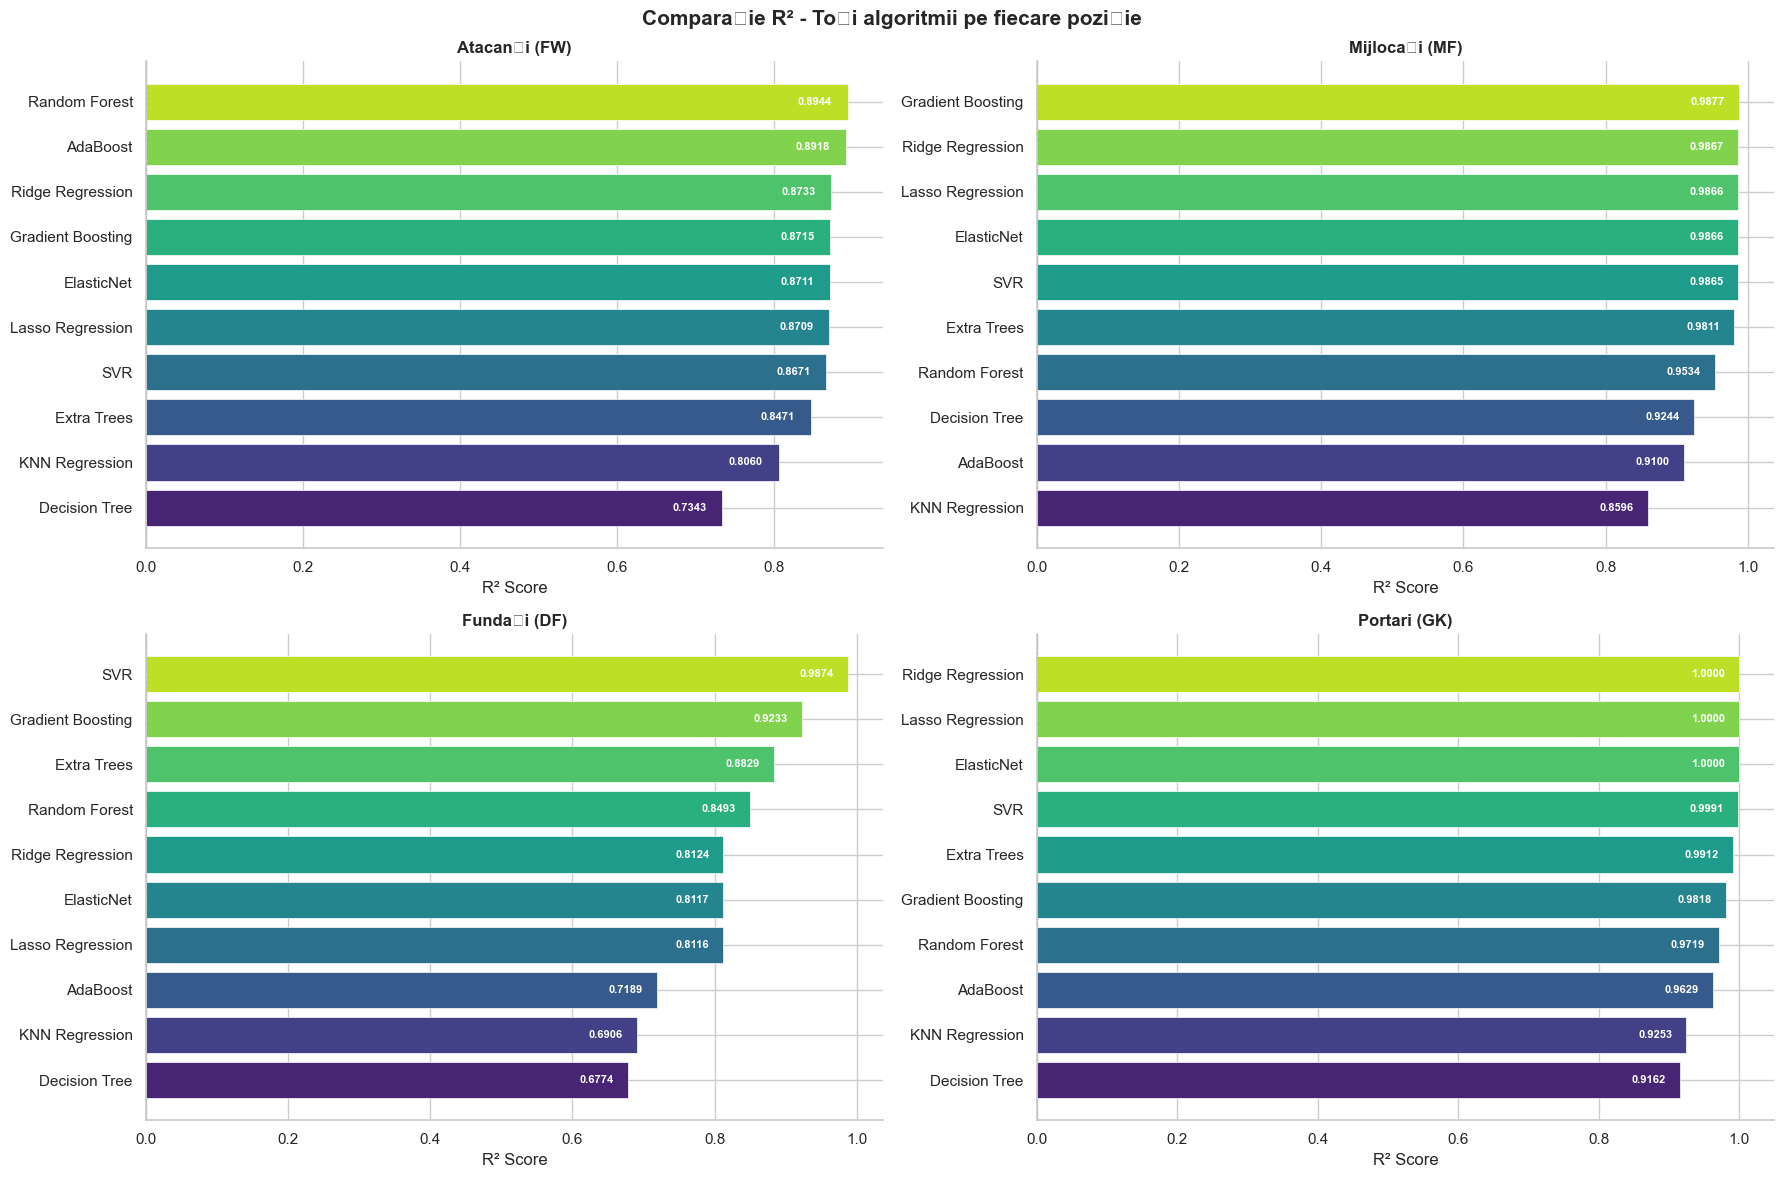

In [46]:
def plot_comparatie_modele(rez_dict):
    """Grafic comparativ R² pentru toate pozițiile și toți algoritmii"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Comparație R² - Toți algoritmii pe fiecare poziție', fontsize=15, fontweight='bold')

    culori = plt.cm.viridis(np.linspace(0.1, 0.9, 10))

    for ax, (pos_name, rez) in zip(axes.flatten(), rez_dict.items()):
        if rez is None:
            ax.set_visible(False)
            continue
        rez_sorted = rez.sort_values('R²')
        bars = ax.barh(rez_sorted['Model'], rez_sorted['R²'],
                       color=culori[:len(rez_sorted)], edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, rez_sorted['R²']):
            ax.text(max(val - 0.02, 0.01), bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', ha='right', fontsize=8,
                    color='white', fontweight='bold')
        ax.set_title(pos_name, fontsize=12, fontweight='bold')
        ax.set_xlabel('R² Score')
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


rez_dict = {
    'Atacanți (FW)':  rez_fw,
    'Mijlocași (MF)': rez_mf,
    'Fundași (DF)':   rez_df,
    'Portari (GK)':   rez_gk,
}

plot_comparatie_modele(rez_dict)

In [47]:
# Tabel centralizat: cel mai bun model pe fiecare poziție
print('\n=== CEL MAI BUN MODEL PE FIECARE POZIȚIE ===')
rezumat = []
for pos_name, rez in rez_dict.items():
    if rez is not None:
        top = rez.iloc[0]
        rezumat.append({
            'Poziție': pos_name,
            'Cel mai bun model': top['Model'],
            'R²': top['R²'],
            'RMSE': top['RMSE'],
            'MAE': top['MAE'],
            'CV R² (mean)': top['CV R² (mean)'],
        })
display(pd.DataFrame(rezumat))


=== CEL MAI BUN MODEL PE FIECARE POZIȚIE ===


,Poziție,Cel mai bun model,R²,RMSE,MAE,CV R² (mean)
0,Atacanți (FW),Random Forest,0.8944,1.5697,1.2174,0.7512
1,Mijlocași (MF),Gradient Boosting,0.9877,0.2586,0.1326,0.9841
2,Fundași (DF),SVR,0.9874,0.0710,0.0419,0.9792
3,Portari (GK),Ridge Regression,1.0000,0.0000,0.0000,1.0000


6. Top 5 jucători pe fiecare poziție¶

In [48]:
criterii = {
    'GK': 'Scor_Portar',
    'DF': 'Implicare_Defensiva_90',
    'MF': 'Scor_Playmaker',
    'FW': 'Contributie_Ofensiva',
}

coloane_afisare = {
    'GK': ['Player', 'Squad', 'Comp', 'Age', 'Saves', 'Save%', 'CS', 'GA90', 'Scor_Portar'],
    'DF': ['Player', 'Squad', 'Comp', 'Age', 'TklW', 'Int', 'Fls', 'Implicare_Defensiva_90'],
    'MF': ['Player', 'Squad', 'Comp', 'Age', 'Gls', 'Ast', 'TklW', 'Scor_Playmaker'],
    'FW': ['Player', 'Squad', 'Comp', 'Age', 'Gls', 'Ast', 'SoT', 'G/Sh', 'Contributie_Ofensiva'],
}

pozitii_label = {
    'GK': 'Portari',
    'DF': 'Fundași',
    'MF': 'Mijlocași',
    'FW': 'Atacanți',
}

top5_toate = {}
for pos, criteriu in criterii.items():
    df_pos = df[df['Pos'] == pos].copy()
    cols   = [c for c in coloane_afisare[pos] if c in df_pos.columns]
    top5   = df_pos.nlargest(5, criteriu)[cols].reset_index(drop=True)
    top5.index += 1
    top5_toate[pos] = top5
    print(f'\n=== 🏆 Top 5 {pozitii_label[pos]} (după {criteriu}) ===')
    display(top5)


=== 🏆 Top 5 Portari (după Scor_Portar) ===


,Player,Squad,Comp,Age,Saves,Save%,CS,GA90,Scor_Portar
1,Jean Butez,Como,A,30,79.0,76.7,15.0,0.85,0.920821
2,Mile Svilar,Roma,A,26,98.0,77.8,14.0,0.88,0.902699
3,Mike Maignan,Milan,A,30,87.0,79.4,13.0,0.85,0.891482
4,Joan García,Barcelona,Liga,24,66.0,79.5,12.0,0.76,0.859551
5,Ivan Provedel,Lazio,A,32,87.0,78.6,12.0,1.00,0.847124



=== 🏆 Top 5 Fundași (după Implicare_Defensiva_90) ===


,Player,Squad,Comp,Age,TklW,Int,Fls,Implicare_Defensiva_90
1,Vanderson,Monaco,1,24,13,19,15,4.698972
2,Oliver Scarles,West Ham United,League,20,18,13,6,4.240766
3,Gabriel Suazo,Sevilla,Liga,28,53,19,24,4.088586
4,Jan Ziółkowski,Roma,A,20,14,7,11,3.954802
5,Mahamadou Nagida,Rennes,1,20,9,17,11,3.933434



=== 🏆 Top 5 Mijlocași (după Scor_Playmaker) ===


,Player,Squad,Comp,Age,Gls,Ast,TklW,Scor_Playmaker
1,Bruno Fernandes,Manchester Utd,League,31,8,18,31,19.620131
2,Michael Olise,Bayern Munich,,24,12,18,11,19.067920
3,Federico Dimarco,Inter,A,28,6,14,31,16.168320
4,Luis Díaz,Bayern Munich,,29,15,13,13,14.128577
5,Julian Ryerson,Dortmund,,28,0,12,18,13.360863



=== 🏆 Top 5 Atacanți (după Contributie_Ofensiva) ===


,Player,Squad,Comp,Age,Gls,Ast,SoT,G/Sh,Contributie_Ofensiva
1,Erling Haaland,Manchester City,League,25,23,7,51,0.18,27
2,Harry Kane,Bayern Munich,,32,32,5,62,0.20,27
3,Deniz Undav,Stuttgart,,29,18,6,43,0.16,24
4,Lautaro Martínez,Inter,A,28,16,4,35,0.19,20
5,João Pedro,Chelsea,League,24,14,5,27,0.21,19


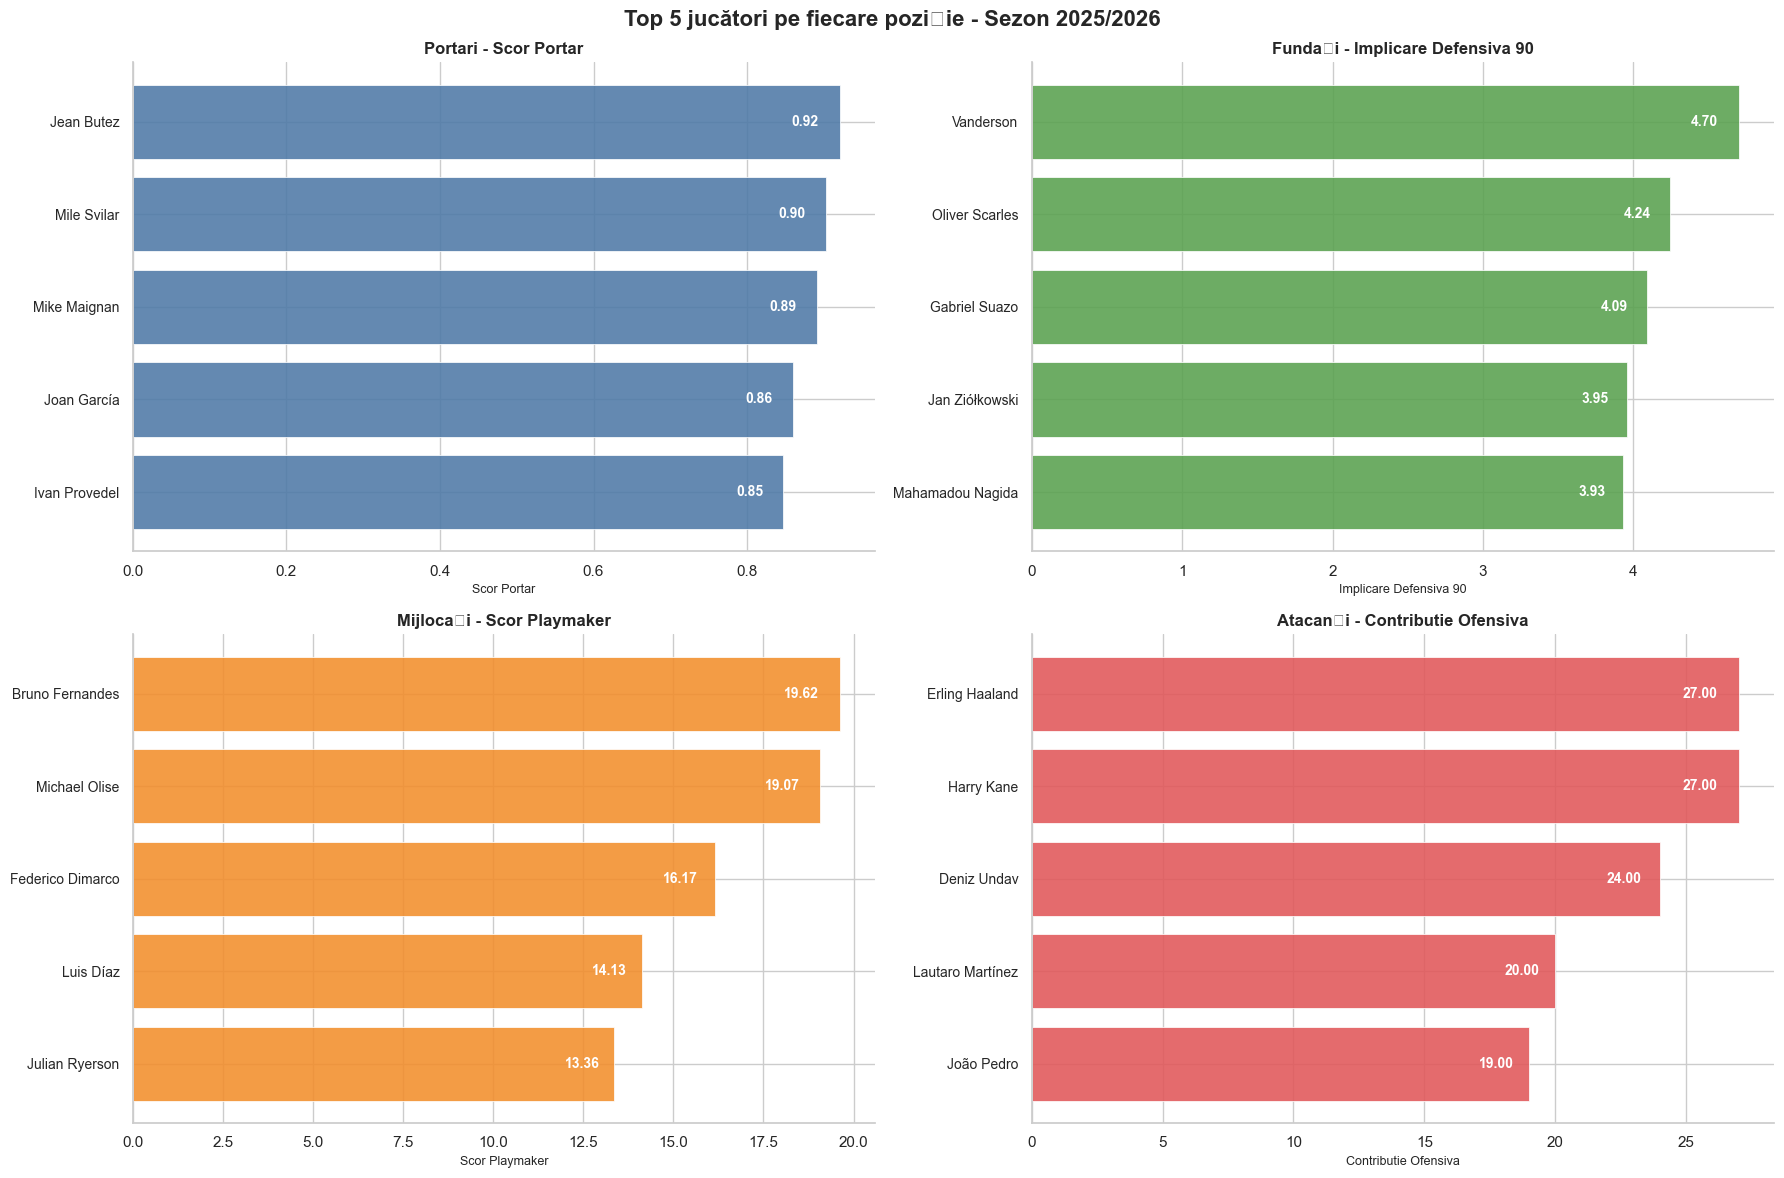

In [49]:
# Vizualizare Top 5 pe toate pozițiile
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Top 5 jucători pe fiecare poziție - Sezon 2025/2026',
             fontsize=16, fontweight='bold')

culori_pos = {'GK': '#4e79a7', 'DF': '#59a14f', 'MF': '#f28e2b', 'FW': '#e15759'}

for ax, (pos, criteriu) in zip(axes.flatten(), criterii.items()):
    df_pos = df[df['Pos'] == pos].copy()
    top5   = df_pos.nlargest(5, criteriu)[['Player', criteriu]].reset_index(drop=True)

    bars = ax.barh(top5['Player'][::-1], top5[criteriu][::-1],
                   color=culori_pos[pos], alpha=0.88, edgecolor='white', linewidth=0.6)

    for bar, val in zip(bars, top5[criteriu][::-1]):
        ax.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='right', fontsize=10,
                color='white', fontweight='bold')

    ax.set_title(f'{pozitii_label[pos]} - {criteriu.replace("_", " ")}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(criteriu.replace('_', ' '), fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

7. Feature Importance – cel mai bun model pe fiecare poziție

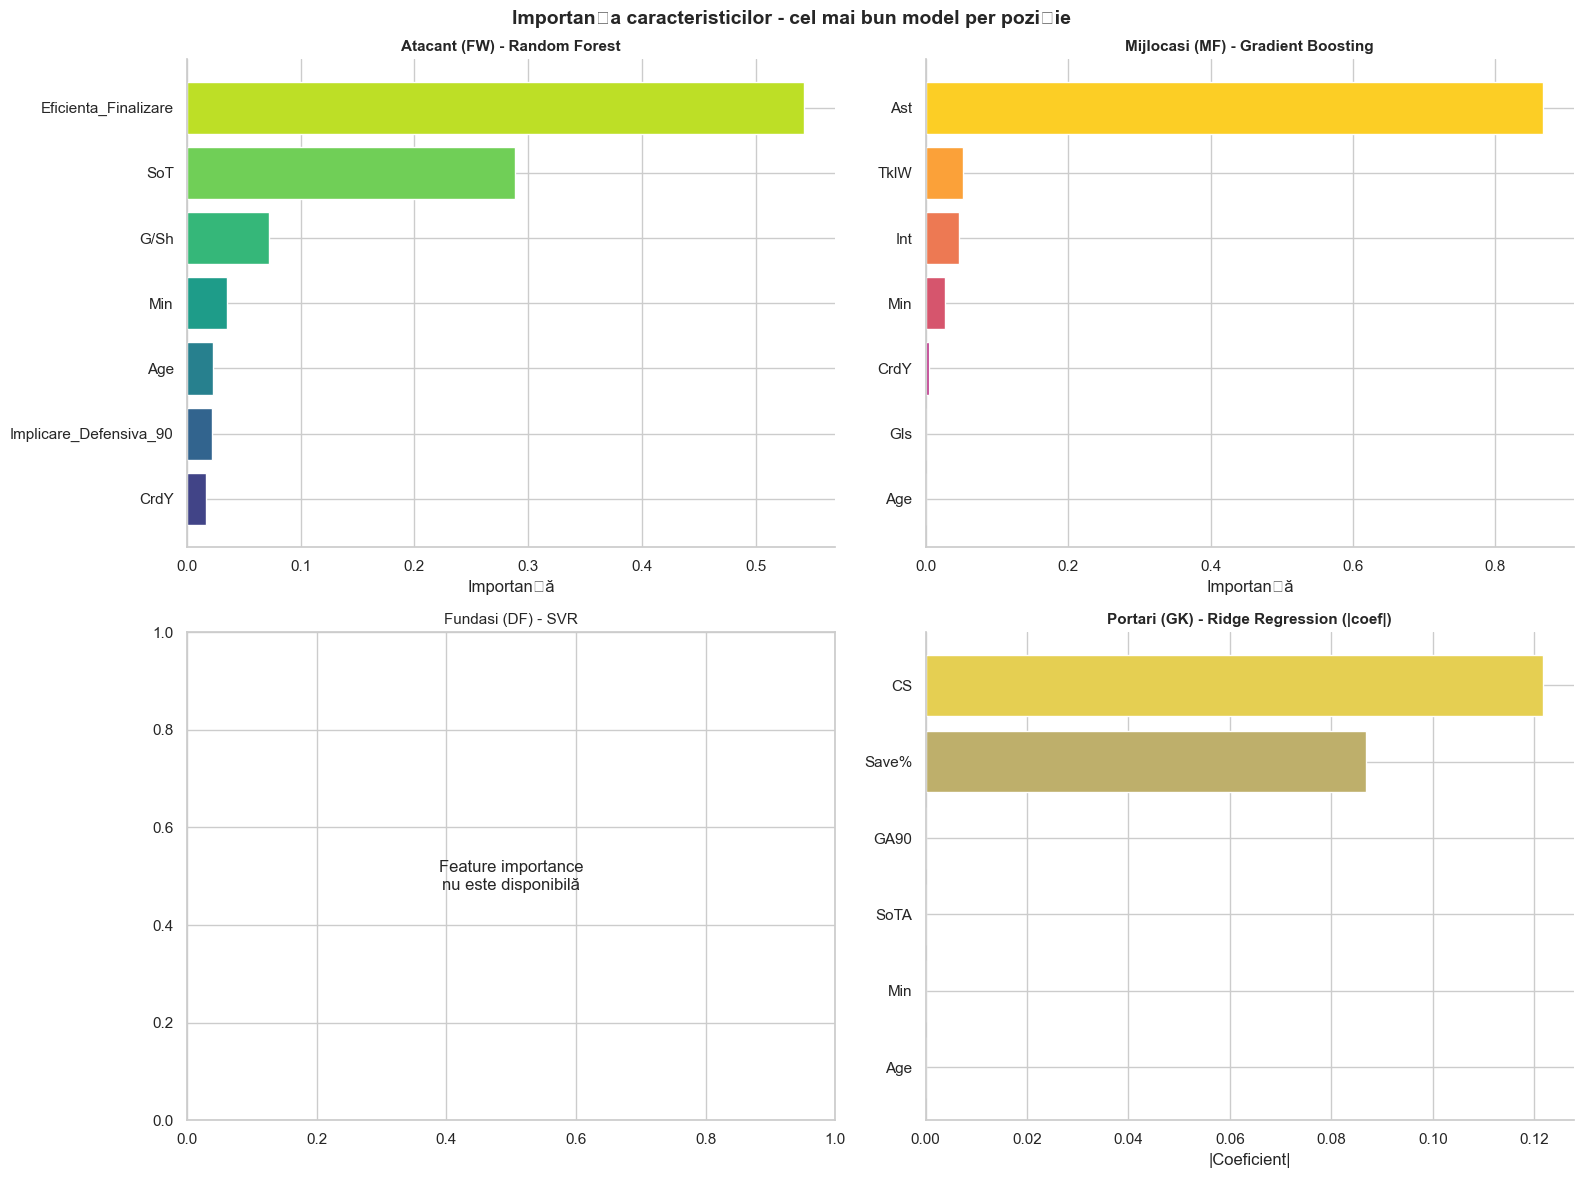

In [52]:
def plot_feature_importance(model, features, title, ax, color='viridis'):
    """Afișează importanța caracteristicilor dacă modelul o suportă."""
    if hasattr(model, 'feature_importances_'):
        imp = pd.DataFrame({'Caracteristică': features,
                            'Importanță': model.feature_importances_})
        imp = imp.sort_values('Importanță', ascending=True)
        ax.barh(imp['Caracteristică'], imp['Importanță'],
                color=plt.cm.get_cmap(color)(np.linspace(0.2, 0.9, len(imp))))
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Importanță')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    elif hasattr(model, 'coef_'):
        coef = np.abs(model.coef_)
        imp = pd.DataFrame({'Caracteristică': features, 'Importanță': coef})
        imp = imp.sort_values('Importanță', ascending=True)
        ax.barh(imp['Caracteristică'], imp['Importanță'],
                color=plt.cm.get_cmap(color)(np.linspace(0.2, 0.9, len(imp))))
        ax.set_title(title + ' (|coef|)', fontsize=11, fontweight='bold')
        ax.set_xlabel('|Coeficient|')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'Feature importance\nnu este disponibilă',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Importanța caracteristicilor - cel mai bun model per poziție',
             fontsize=14, fontweight='bold')

config_importance = [
    (rez_fw, models_fw, features_fw, 'Atacant (FW)', 'viridis', axes[0, 0]),
    (rez_mf, models_mf, features_mf, 'Mijlocasi (MF)', 'plasma', axes[0, 1]),
    (rez_df, models_df, features_df, 'Fundasi (DF)', 'magma', axes[1, 0]),
    (rez_gk, models_gk, features_gk, 'Portari (GK)', 'cividis', axes[1, 1]),
]

for rez, models, feats, label, cmap, ax in config_importance:
    if rez is not None:
        best_name = rez.iloc[0]['Model']
        best_model = models[best_name]['model']
        plot_feature_importance(best_model, feats, f'{label} - {best_name}', ax, cmap)

plt.tight_layout()
plt.show()

8. Salvarea rezultatelor

In [51]:
# Salvăm rezultatele brute ale tuturor modelelor
with pd.ExcelWriter('rezultate_brute_modele.xlsx') as writer:
    for pos_name, rez in rez_dict.items():
        if rez is not None:
            sheet = pos_name.replace('(', '').replace(')', '').replace(' ', '_')[:31]
            rez.to_excel(writer, sheet_name=sheet, index=True)

# Salvăm top 5 jucători per poziție
with pd.ExcelWriter('top5_jucatori_pozitii.xlsx') as writer:
    for pos, top5 in top5_toate.items():
        top5.to_excel(writer, sheet_name=pozitii_label[pos], index=True)

# Salvăm și CSV-ul final
df.to_csv('players-final.csv', index=False)

print('✅ Fișierele au fost salvate:')
print('   - rezultate_brute_modele.xlsx  (R², RMSE, MAE, CV scores pentru toți algoritmii)')
print('   - top5_jucatori_pozitii.xlsx   (Top 5 jucători pe fiecare poziție)')
print('   - players-final.csv            (setul de date complet cu toate feature-urile)')

✅ Fișierele au fost salvate:
   - rezultate_brute_modele.xlsx  (R², RMSE, MAE, CV scores pentru toți algoritmii)
   - top5_jucatori_pozitii.xlsx   (Top 5 jucători pe fiecare poziție)
   - players-final.csv            (setul de date complet cu toate feature-urile)


In [ ]:
df[df['Pos'] == 'FW'].nlargest(10, 'Contributie_Ofensiva')[['Player', 'Squad', 'Comp', 'Gls', 'Ast', 'Contributie_Ofensiva']].reset_index(drop=True)